# Lección 0.1 · Colab como laboratorio digital

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/juvenalyosa/bioinformatica-practica/blob/main/modulo-00-preparacion/0.1_colab_laboratorio.ipynb) [![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai) [![Licencia: MIT](https://img.shields.io/badge/Licencia-MIT-2a78d6.svg)](https://github.com/juvenalyosa/bioinformatica-practica/blob/main/LICENSE)

**Módulo 0 — Preparación del laboratorio digital** · Bioinformática Práctica (Maestría)

👤 **Juvenal Yosa, PhD** · ✉️ [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · 🤖 Copiloto: **Claude** (Anthropic)

| ⏱️ Duración | 📶 Nivel | 🧰 Requisitos |
|---|---|---|
| ~2.5 horas | Introductorio | Ninguno: sólo un navegador y una cuenta de Google |

---

## 🎯 Objetivos de aprendizaje

Al terminar esta clase usted podrá:

1. **Explicar** qué es un notebook y por qué es el "cuaderno de laboratorio" del bioinformático.
2. **Representar** una secuencia de ADN en Python (`str`, `dict`, `numpy`) y calcular su contenido GC.
3. **Justificar** por qué `numpy` es órdenes de magnitud más rápido que un ciclo `for`.
4. **Organizar** datos biológicos en tablas con `pandas`.
5. **Modelar** la variación del contenido GC con la distribución binomial y **verificarlo** con una simulación.
6. **Construir** figuras con estándar de publicación usando el estilo del curso.

## 🗺️ Mapa de la clase

1. El notebook: su cuaderno de laboratorio
2. Python como pipeta: el ADN como texto
3. `numpy`: la pipeta multicanal
4. `pandas`: la hoja de registro del laboratorio
5. 🧪 Experimento: ¿cuánto varía el GC por puro azar? (modelo binomial)
6. 🎬 Animación y 🖱️ gráfico interactivo: una ventana deslizante recorre un genoma
7. Anatomía de una figura profesional
8. Ejercicios, resumen y lecturas

## 1. El notebook: su cuaderno de laboratorio

En un laboratorio húmedo usted lleva un **cuaderno** donde escribe el protocolo, anota lo que hizo y pega los
resultados: la foto del gel, la tabla de absorbancias, la curva de crecimiento. Si seis meses después alguien pregunta
"¿cómo obtuviste esta banda?", la respuesta está en el cuaderno, junto a la banda.

Un **notebook** es ese mismo cuaderno, pero digital y **ejecutable**: el protocolo es texto, el experimento es
código, y los resultados (tablas, gráficas, animaciones) aparecen justo debajo del código que los produjo. La gran
ventaja sobre el papel es que el "experimento" se puede **volver a correr** con un clic, con otros datos o con otro
parámetro, y ver de inmediato cómo cambia el resultado.

Un notebook tiene dos tipos de **celdas**:

| Celda | Equivale a... | Qué contiene |
|---|---|---|
| 📝 **Texto** (Markdown) | El protocolo escrito | Explicaciones, ecuaciones, imágenes |
| ▶️ **Código** (Python) | El experimento | Instrucciones que la computadora ejecuta |

**Google Colab** es un laboratorio *prestado en la nube*: cuando usted abre un notebook, Google le presta una
computadora (con Python, `numpy`, `pandas`, `matplotlib`, `plotly` y cientos de paquetes ya instalados) durante
algunas horas. Usted no instala nada: todo corre en un servidor y su navegador sólo muestra el cuaderno.
Dos consecuencias importantes:

* **La mesa se limpia cada día.** Cuando la sesión termina (o usted cierra la pestaña un buen rato), la máquina se
  borra: archivos descargados y variables desaparecen. El notebook (el cuaderno) sí se guarda.
* **El orden importa.** Las celdas se ejecutan en el orden en que usted las corre, no en el orden en que aparecen.
  Si algo falla de forma extraña: `Entorno de ejecución → Reiniciar y ejecutar todo`.

**Un ejemplo de por qué importa el orden.** Suponga tres celdas: la celda A dice `x = 5`, la B dice `x = x * 2` y
la C muestra `x`. Si ejecuta A → B → C verá `10`. Si ejecuta B una segunda vez antes de C verá `20`, aunque el
cuaderno "se lea" igual de arriba abajo. El número entre corchetes a la izquierda de cada celda (`[3]`, `[4]`…) indica
en qué orden se ejecutaron realmente.

### Atajos esenciales

| Acción | Atajo |
|---|---|
| Ejecutar celda y pasar a la siguiente | `Shift + Enter` |
| Ejecutar celda y quedarse | `Ctrl + Enter` |
| Nueva celda de código debajo | `Ctrl + M` y luego `B` |
| Convertir en celda de texto | `Ctrl + M` y luego `M` |

Empecemos preparando el entorno. Esta celda descarga el **estilo gráfico del curso** (colores validados para
personas con daltonismo, tipografía, rejillas discretas) y lo aplica a todas las figuras.

In [1]:
# ⚙️ Configuración del entorno (ejecute esta celda primero)
# Bioinformática Práctica · Juvenal Yosa, PhD · Copiloto: Claude
import os, sys, urllib.request

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

# Descarga el estilo gráfico del curso (en Colab) o lo toma del repositorio (local)
STYLE_URL = "https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/utils/estilo_curso.py"
if os.path.exists("../utils/estilo_curso.py"):
    sys.path.insert(0, "../utils")
elif not os.path.exists("estilo_curso.py"):
    urllib.request.urlretrieve(STYLE_URL, "estilo_curso.py")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import estilo_curso as ec

ec.set_style()
print("Entorno listo ✔  |  Colab:", IN_COLAB)

Entorno listo ✔  |  Colab: False


## 2. Python como pipeta: el ADN como texto

Una molécula de ADN es un polímero químico, pero la información que lleva depende sólo del **orden** de sus cuatro
bases. Por eso, para la computadora, el ADN es simplemente un **texto** escrito con un alfabeto de cuatro letras:
`A`, `C`, `G`, `T`. Casi todo lo que haremos en el curso empieza con cuatro verbos sobre ese texto: **leer, cortar,
contar y comparar** — del mismo modo que casi todo en la mesa de trabajo empieza por tomar, mover y medir volúmenes
con una pipeta.

En Python un texto es un `str` (*string*). Cada letra ocupa una posición numerada; podemos pedir una letra
(`dna[5]`), un tramo (`dna[0:3]`) o preguntar si un motivo aparece dentro (`"GATATC" in dna`).
Veamos las operaciones básicas:

In [2]:
dna = "ATGGCGTACGCTAGCTAGGCTTAACGGCGCGATATCGCGTAG"

print("Longitud:", len(dna), "pb")        # pb = pares de bases
print("Primera base:", dna[0])            # Python cuenta desde 0
print("Primer codón:", dna[0:3])          # [inicio:fin) -> el fin NO se incluye
print("Últimos 3 nt:", dna[-3:])          # índices negativos cuentan desde el final
print("Número de G:", dna.count("G"))
print("¿Contiene el sitio EcoRV (GATATC)?", "GATATC" in dna)

Longitud: 42 pb
Primera base: A
Primer codón: ATG
Últimos 3 nt: TAG
Número de G: 14
¿Contiene el sitio EcoRV (GATATC)? True


> ⚠️ **Cuidado con el índice 0.** Los biólogos numeran la primera base como la posición 1; Python la numera como 0.
> Piense en una **regla**: la primera marca es el 0 y el primer centímetro es el intervalo `[0, 1)`.
> Por eso `dna[0:3]` significa "desde la marca 0 hasta la marca 3", es decir, las posiciones biológicas 1, 2 y 3.

### Contar bases con un diccionario

Un `dict` asocia **claves** con **valores**. Piense en una gradilla con cuatro tubos rotulados `A`, `C`, `G` y `T`:
recorremos la secuencia letra por letra y, cada vez que vemos una base, añadimos una "gota" (sumamos 1) al tubo con
esa etiqueta. Al final, el contenido de cada tubo es el conteo de esa base.

In [3]:
def base_counts(seq: str) -> dict:
    """Cuenta cuántas veces aparece cada base en la secuencia."""
    counts = {"A": 0, "C": 0, "G": 0, "T": 0}
    for base in seq.upper():          # recorremos la secuencia base por base
        if base in counts:
            counts[base] += 1
    return counts

counts = base_counts(dna)
counts

{'A': 9, 'C': 10, 'G': 14, 'T': 9}

### El contenido GC: nuestra primera métrica bioinformática

Los pares **G–C** se unen con **tres** puentes de hidrógeno y los pares **A–T** con **dos**. Por eso el
**contenido GC** influye en la estabilidad térmica del ADN, en la eficiencia de la PCR y en el diseño de *primers*;
además varía muchísimo entre especies y es una "huella" del genoma.

$$
\boxed{\;\mathrm{GC}(s) \;=\; \frac{n_G + n_C}{n_A + n_C + n_G + n_T}\;}
$$

| Símbolo | Significado |
|---|---|
| $s$ | la secuencia que analizamos |
| $n_G,\ n_C$ | número de guaninas y citosinas en $s$ |
| $n_A + n_C + n_G + n_T$ | total de bases válidas (ignoramos `N` = base desconocida) |
| $\mathrm{GC}(s)$ | una **proporción** entre 0 y 1 (o un porcentaje si la multiplicamos por 100) |

**Ejemplo a mano.** Para $s =$ `GATTACA`: $n_G = 1$, $n_C = 1$, $n_A = 3$, $n_T = 2$. Entonces

$$
\mathrm{GC}(\texttt{GATTACA}) = \frac{1 + 1}{3 + 1 + 1 + 2} = \frac{2}{7} \approx 0.286 \;\; (28.6\,\%)
$$

Ahora hagamos que la computadora lo calcule, primero con `GATTACA` (para comprobar que el código coincide con nuestra
cuenta) y luego con la secuencia de ejemplo. **Comprobar el código con un caso resuelto a mano** es un hábito que le
ahorrará muchos errores.

In [4]:
def gc_content(seq: str) -> float:
    """Proporción de G + C sobre el total de bases válidas."""
    c = base_counts(seq)
    total = sum(c.values())
    return (c["G"] + c["C"]) / total if total else float("nan")

print(f"GC('GATTACA') = {gc_content('GATTACA'):.3f}  ← debe dar 2/7 = 0.286")
print(f"GC(dna)       = {gc_content(dna):.3f}  ({gc_content(dna):.1%})")

GC('GATTACA') = 0.286  ← debe dar 2/7 = 0.286
GC(dna)       = 0.571  (57.1%)


Visualicemos la composición. Observe los elementos de una figura profesional: **título que dice qué se muestra**,
subtítulo con el contexto, **etiquetas directas** sobre las barras (sin obligar al lector a adivinar valores) y
rejilla discreta. Los colores de nucleótidos siguen la convención de los *sequence logos* y siempre van con su letra.

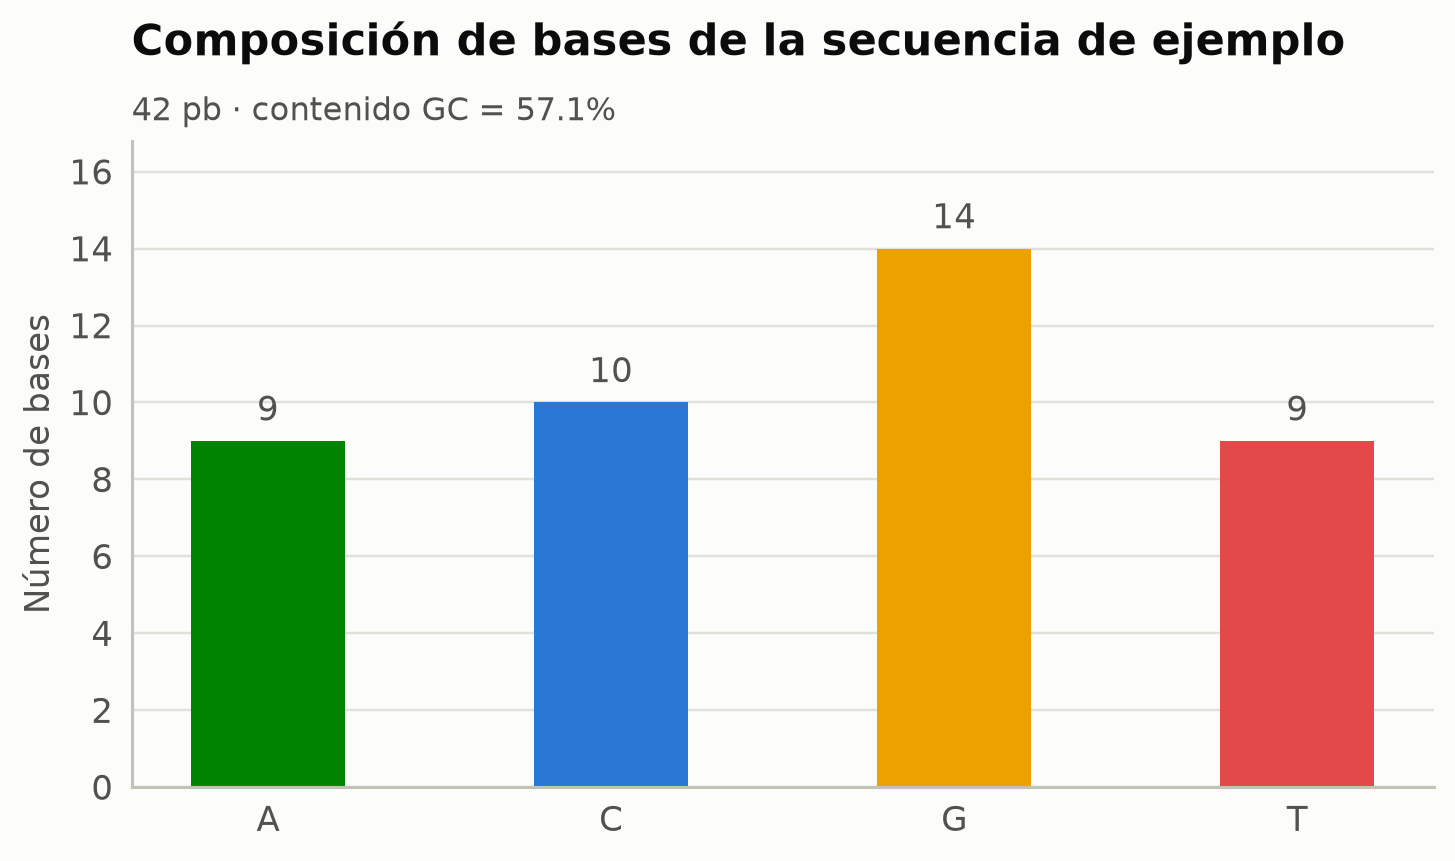

In [5]:
fig, ax = plt.subplots(figsize=(6.5, 3.8))
bases = list(counts)
values = [counts[b] for b in bases]
bars = ax.bar(bases, values, color=ec.nuc_colors("".join(bases)), width=0.45)
ax.bar_label(bars, padding=4, color=ec.INK_2)
ax.set_ylabel("Número de bases")
ax.set_ylim(0, max(values) * 1.2)
ec.title(ax, "Composición de bases de la secuencia de ejemplo",
         f"{len(dna)} pb · contenido GC = {gc_content(dna):.1%}")
plt.show()

## 3. `numpy`: la pipeta multicanal

Contar bases con un ciclo `for` funciona, pero es como llenar una placa de 96 pozos **pozo por pozo** con una pipeta
monocanal: en cada pozo Python "piensa" de nuevo qué hacer (leer la letra, buscarla en el diccionario, sumar…).
`numpy` es la **pipeta multicanal**: se describe la operación una sola vez ("compara todas las letras con G") y se
aplica a millones de elementos de golpe, con código compilado en C por debajo.

¿Importa? Un genoma bacteriano tiene millones de bases; el humano, **3 100 millones**. Si cada base cuesta ~0.1
microsegundos en un ciclo de Python, contar G y C en el genoma humano tomaría varios minutos; vectorizado, segundos.

La idea clave es **representar el ADN como un arreglo de números**. En el código ASCII cada letra es un byte:
`A = 65`, `C = 67`, `G = 71`, `T = 84`. Así `"GATC"` se convierte en `[71, 65, 84, 67]`, y la pregunta "¿es G o C?"
se vuelve una comparación numérica que `numpy` hace sobre todo el arreglo a la vez, produciendo una **máscara** de
verdaderos y falsos: `[True, False, False, True]`. Como `True` vale 1, sumar la máscara da el número de G + C.

In [6]:
def to_array(seq: str) -> np.ndarray:
    """Convierte un str de ADN en un arreglo de bytes (A=65, C=67, G=71, T=84)."""
    return np.frombuffer(seq.upper().encode("ascii"), dtype=np.uint8)

def gc_content_np(seq: str) -> float:
    arr = to_array(seq)
    is_gc = (arr == ord("G")) | (arr == ord("C"))      # máscara booleana, sin ciclos
    is_valid = np.isin(arr, [ord(b) for b in "ACGT"])
    return is_gc.sum() / is_valid.sum()

print(to_array(dna[:10]), "←", dna[:10])
print(f"GC con numpy = {gc_content_np(dna):.3f}")

[65 84 71 71 67 71 84 65 67 71] ← ATGGCGTACG
GC con numpy = 0.571


### 🧪 Mini-experimento: ¿cuánto más rápido es `numpy`?

> 🤔 **Antes de ejecutar, prediga:** si la secuencia es 1 000 veces más larga, ¿cuánto más tardará cada método?
> ¿Será `numpy` 2 veces más rápido? ¿10? ¿100? Anote su apuesta y compárela con el resultado.

Generamos secuencias aleatorias de longitud creciente (de mil a un millón de bases) y medimos el tiempo de ambas
versiones. Usamos un **generador aleatorio con semilla** (`default_rng(42)`) para que su resultado sea reproducible
— hablaremos de esto a fondo en la Lección 0.3.

In [7]:
import time

rng = np.random.default_rng(42)

def random_dna(n: int, gc: float = 0.5, rng=rng) -> str:
    """Secuencia aleatoria de longitud n con probabilidad `gc` de que cada base sea G o C."""
    p = [(1 - gc) / 2, gc / 2, gc / 2, (1 - gc) / 2]     # P(A), P(C), P(G), P(T)
    return "".join(rng.choice(list("ACGT"), size=n, p=p))

def best_time(func, arg, repeats=3):
    """Mejor tiempo de varias repeticiones (reduce el ruido de la máquina)."""
    times = []
    for _ in range(repeats):
        t0 = time.perf_counter(); func(arg); times.append(time.perf_counter() - t0)
    return min(times)

lengths = np.logspace(3, 6, 7).astype(int)
bench = pd.DataFrame({
    "length": lengths,
    "for_loop_s": [best_time(gc_content, random_dna(n)) for n in lengths],
    "numpy_s":    [best_time(gc_content_np, random_dna(n)) for n in lengths],
})
bench["speedup"] = bench["for_loop_s"] / bench["numpy_s"]
bench.style.format({"for_loop_s": "{:.2e}", "numpy_s": "{:.2e}", "speedup": "{:.0f}×"})

,length,for_loop_s,numpy_s,speedup
0,1000,8.41e-05,2.00e-05,4×
1,3162,2.92e-04,2.31e-05,13×
2,10000,9.52e-04,3.81e-05,25×
3,31622,1.24e-03,8.49e-05,15×
4,100000,4.07e-03,2.41e-04,17×
5,316227,1.97e-02,8.17e-04,24×
6,1000000,6.13e-02,5.14e-03,12×


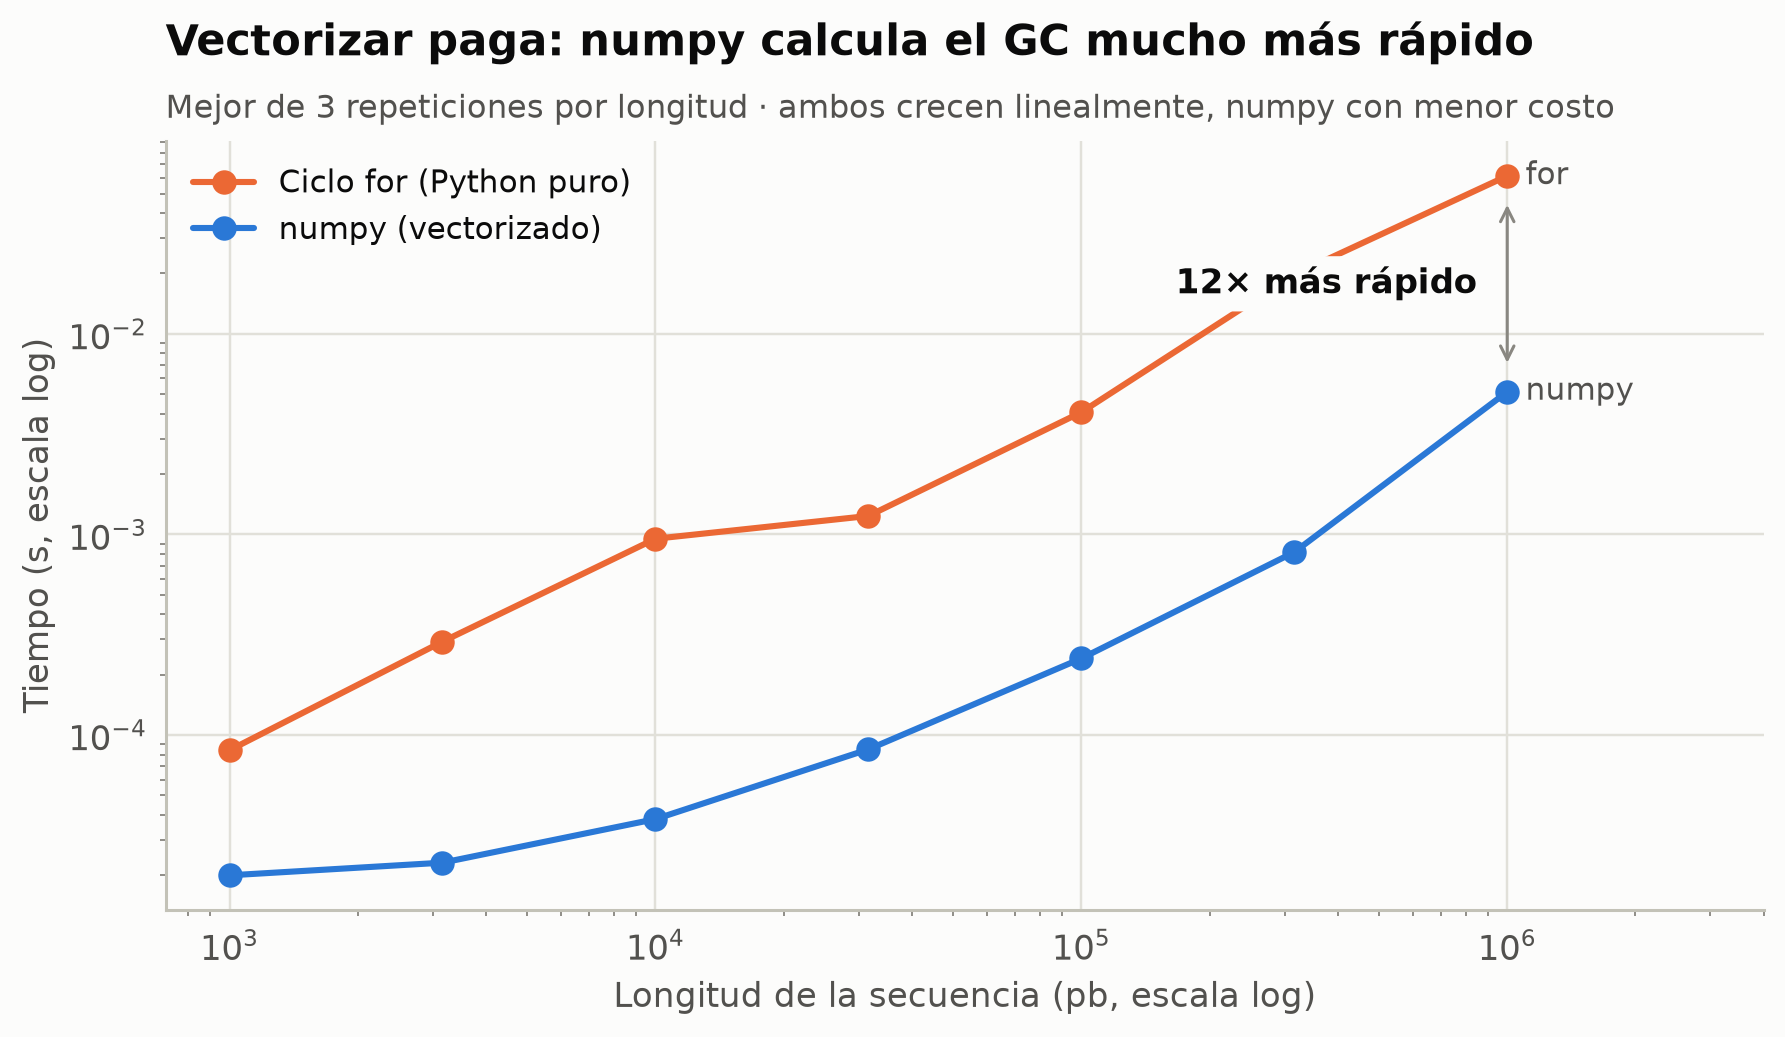

In [8]:
fig, ax = plt.subplots(figsize=(8, 4.6))
ax.loglog(bench["length"], bench["for_loop_s"], "o-", color=ec.ORANGE, label="Ciclo for (Python puro)")
ax.loglog(bench["length"], bench["numpy_s"], "o-", color=ec.BLUE, label="numpy (vectorizado)")
last = bench.iloc[-1]
ec.label_end(ax, last["length"], last["for_loop_s"], "for")
ec.label_end(ax, last["length"], last["numpy_s"], "numpy")
ax.annotate("", xy=(last["length"], last["numpy_s"] * 1.3), xytext=(last["length"], last["for_loop_s"] / 1.3),
            arrowprops=dict(arrowstyle="<->", color=ec.MUTED, lw=1))
ax.annotate(f"{last['speedup']:.0f}× más rápido", xy=(last["length"], np.sqrt(last["for_loop_s"] * last["numpy_s"])),
            xytext=(-10, 0), textcoords="offset points", ha="right", va="center", color=ec.INK, fontsize=11,
            fontweight="bold", bbox=dict(boxstyle="round,pad=0.3", fc=ec.SURFACE, ec="none"))
ax.set_xlabel("Longitud de la secuencia (pb, escala log)")
ax.set_ylabel("Tiempo (s, escala log)")
ax.set_xlim(right=bench["length"].max() * 4)
ax.grid(True, which="major", axis="both")
ax.legend(loc="upper left")
ec.title(ax, "Vectorizar paga: numpy calcula el GC mucho más rápido",
         "Mejor de 3 repeticiones por longitud · ambos crecen linealmente, numpy con menor costo")
plt.show()

> 🔎 **Interpretación.** Ambas rectas tienen pendiente ≈ 1 en escala log–log: el tiempo crece **linealmente** con la
> longitud, $t \propto n$. La diferencia es la **constante**: `numpy` evita el costo de interpretar cada iteración en
> Python. Para el genoma humano, esa constante es la diferencia entre segundos y muchos minutos.

## 4. `pandas`: la hoja de registro del laboratorio

Casi todos los datos biológicos terminan en una **tabla**: muestras × genes, variantes × pacientes, organismos ×
características. `pandas` es la hoja de cálculo del laboratorio, pero programable: cada fila es una observación y
cada columna una variable. La diferencia con Excel es que cada paso — filtrar, ordenar, agrupar, resumir — queda
escrito como código, así que se repite exactamente sobre datos nuevos y no hay celdas modificadas "a mano" que nadie
recuerda.

Las tres operaciones que usará todo el tiempo:

| Operación | En palabras | En `pandas` |
|---|---|---|
| Ordenar | "de menor a mayor GC" | `df.sort_values("gc_percent")` |
| Filtrar | "sólo las bacterias" | `df.query("domain == 'Bacteria'")` |
| Agrupar y resumir | "GC promedio por dominio" | `df.groupby("domain")["gc_percent"].mean()` |

Construyamos una tabla con organismos modelo reales (valores aproximados de sus genomas de referencia):

In [9]:
genomes = pd.DataFrame({
    "organism": ["Plasmodium falciparum", "Saccharomyces cerevisiae", "Arabidopsis thaliana",
                 "Homo sapiens", "Escherichia coli K-12", "Streptomyces coelicolor"],
    "domain":   ["Eukarya", "Eukarya", "Eukarya", "Eukarya", "Bacteria", "Bacteria"],
    "genome_mb": [23.3, 12.1, 135.0, 3100.0, 4.6, 8.7],
    "gc_percent": [19.4, 38.3, 36.0, 40.9, 50.8, 72.1],
})
genomes.sort_values("gc_percent")

,organism,domain,genome_mb,gc_percent
0,Plasmodium falciparum,Eukarya,23.3,19.4
2,Arabidopsis thaliana,Eukarya,135.0,36.0
1,Saccharomyces cerevisiae,Eukarya,12.1,38.3
3,Homo sapiens,Eukarya,3100.0,40.9
4,Escherichia coli K-12,Bacteria,4.6,50.8
5,Streptomyces coelicolor,Bacteria,8.7,72.1


In [10]:
# Resumen por dominio: una línea de código
genomes.groupby("domain")["gc_percent"].agg(["mean", "min", "max", "count"]).round(1)

,mean,min,max,count
domain,,,,
Bacteria,61.4,50.8,72.1,2
Eukarya,33.6,19.4,40.9,4


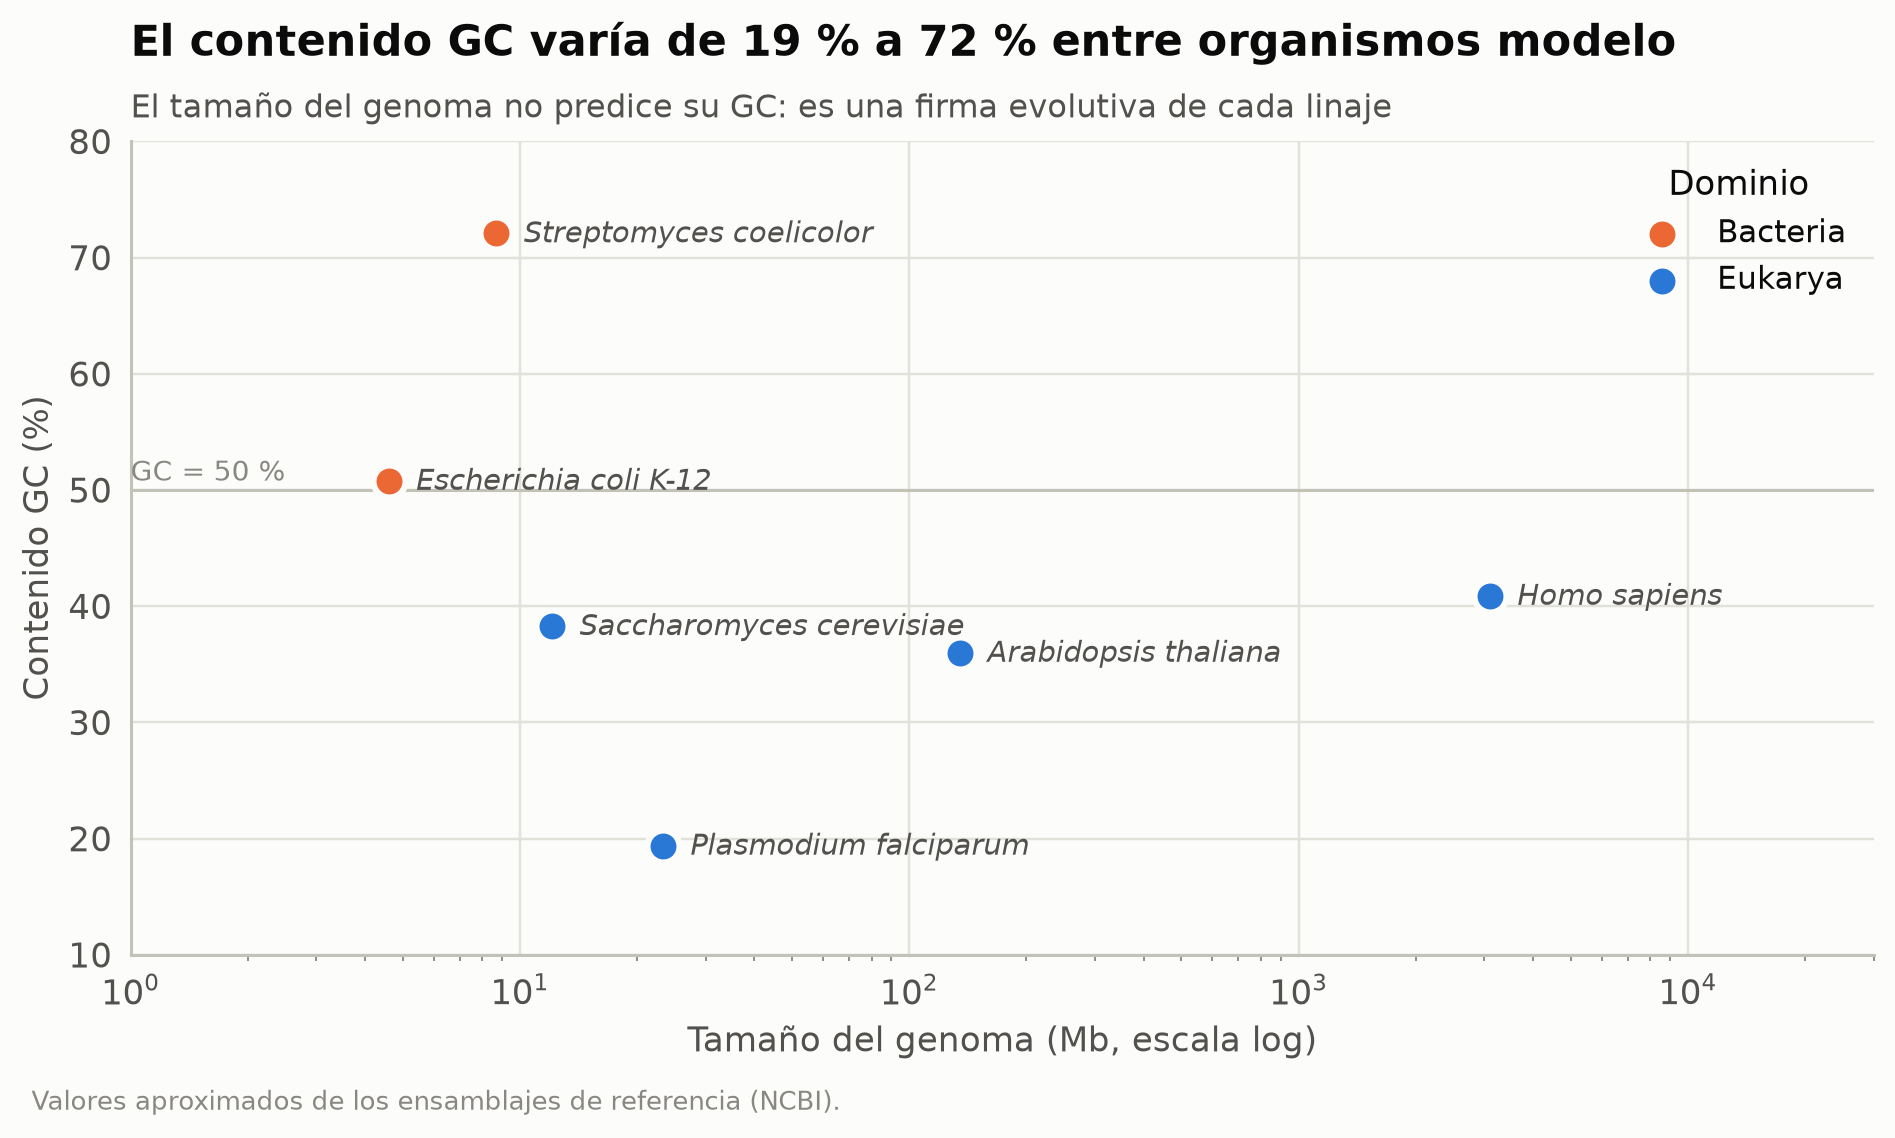

In [11]:
fig, ax = plt.subplots(figsize=(8.5, 4.8))
colors = {"Eukarya": ec.BLUE, "Bacteria": ec.ORANGE}
for domain, sub in genomes.groupby("domain"):
    ax.scatter(sub["genome_mb"], sub["gc_percent"], s=110, color=colors[domain], label=domain,
               edgecolor=ec.SURFACE, linewidth=2, zorder=3)
for _, r in genomes.iterrows():
    ax.annotate(r["organism"], (r["genome_mb"], r["gc_percent"]), xytext=(9, -3),
                textcoords="offset points", fontsize=9.5, color=ec.INK_2, style="italic")
ax.axhline(50, color=ec.BASELINE, lw=1, zorder=1)
ax.text(1.0, 50.8, "GC = 50 %", color=ec.MUTED, fontsize=9)
ax.set_xscale("log")
ax.set_xlim(1, 30000)
ax.set_ylim(10, 80)
ax.set_xlabel("Tamaño del genoma (Mb, escala log)")
ax.set_ylabel("Contenido GC (%)")
ax.grid(True, axis="both")
ax.legend(title="Dominio", loc="upper right")
ec.title(ax, "El contenido GC varía de 19 % a 72 % entre organismos modelo",
         "El tamaño del genoma no predice su GC: es una firma evolutiva de cada linaje")
ec.source(fig, "Valores aproximados de los ensamblajes de referencia (NCBI).")
plt.show()

### 🖱️ Versión interactiva

Una figura estática es ideal para un artículo; para **explorar** es mejor una interactiva. `plotly` genera gráficos
que responden al ratón: pase el cursor sobre cada punto para ver sus datos, arrastre para hacer zoom y haga doble
clic para volver a la vista completa. Un clic en la leyenda oculta o muestra un grupo.

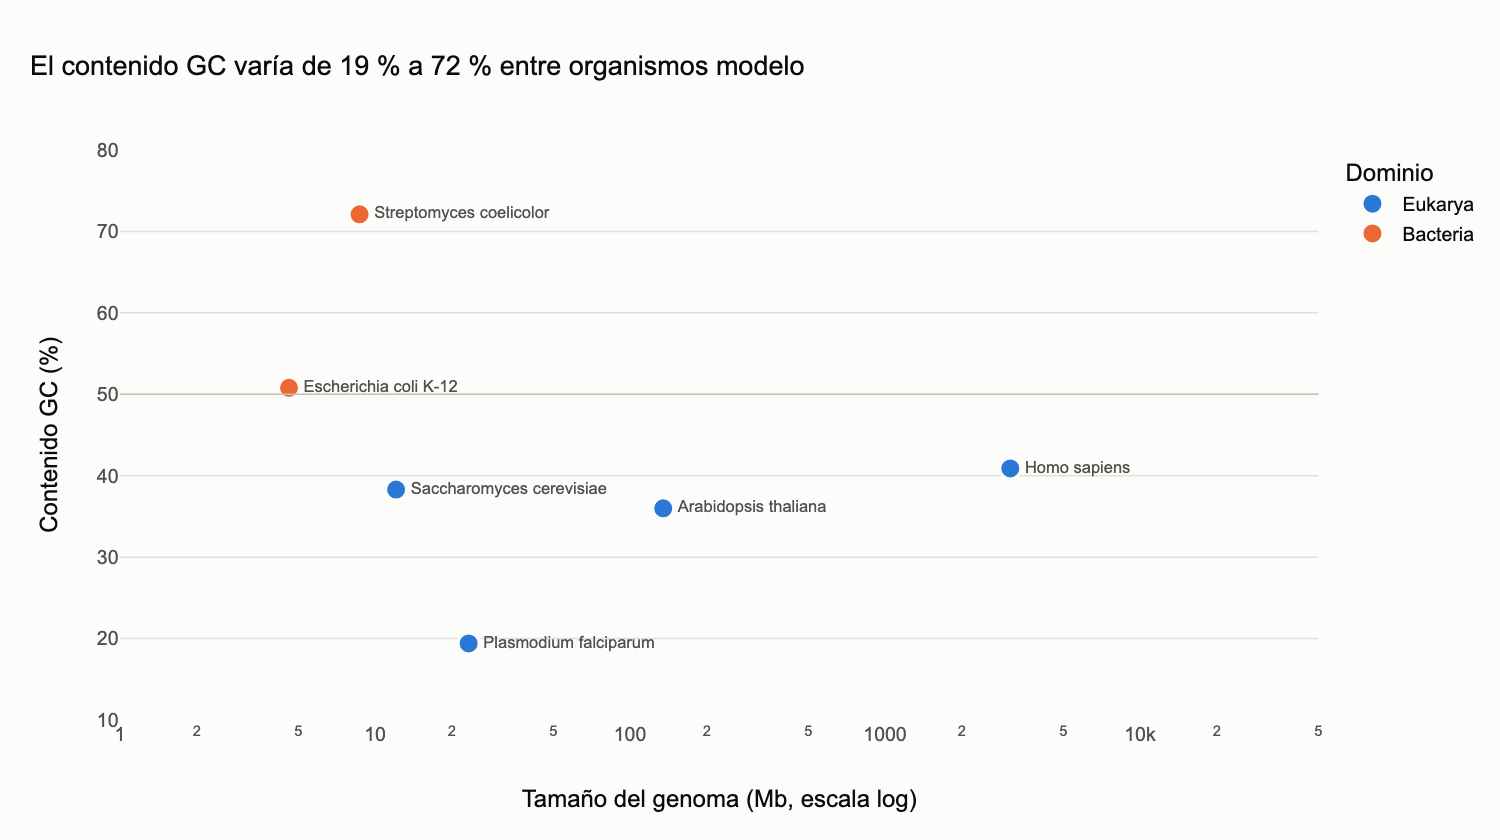

In [12]:
import plotly.express as px
import plotly.graph_objects as go

facts = {
    "Plasmodium falciparum": "Parásito de la malaria; uno de los genomas más ricos en A+T conocidos",
    "Saccharomyces cerevisiae": "Levadura del pan y la cerveza; primer eucariota secuenciado (1996)",
    "Arabidopsis thaliana": "Planta modelo; primer genoma vegetal secuenciado (2000)",
    "Homo sapiens": "Nuestro genoma: ~3 100 Mb y ~20 000 genes codificantes",
    "Escherichia coli K-12": "Bacteria modelo de laboratorio; genoma publicado en 1997",
    "Streptomyces coelicolor": "Productora de antibióticos; genoma muy rico en G+C",
}
gi = genomes.assign(fact=genomes["organism"].map(facts))
fig = px.scatter(gi, x="genome_mb", y="gc_percent", color="domain", log_x=True, text="organism",
                 hover_name="organism",
                 hover_data={"fact": True, "genome_mb": ":,.1f", "gc_percent": ":.1f",
                             "organism": False, "domain": False},
                 color_discrete_map={"Eukarya": ec.BLUE, "Bacteria": ec.ORANGE},
                 labels={"genome_mb": "Tamaño del genoma (Mb, escala log)", "gc_percent": "Contenido GC (%)",
                         "domain": "Dominio", "fact": "Dato"},
                 title="El contenido GC varía de 19 % a 72 % entre organismos modelo")
fig.update_traces(marker=dict(size=14, line=dict(width=2, color=ec.SURFACE)), textposition="middle right",
                  textfont=dict(size=11, color=ec.INK_2))
fig.add_hline(y=50, line_color=ec.BASELINE, line_width=1)
fig.update_layout(height=480, xaxis_range=[0, 4.7], yaxis_range=[10, 80])
fig.show()

> ✅ **Compruebe su comprensión.** ¿Qué organismo tiene el genoma más grande? ¿Y el GC más extremo? Con la tabla
> `genomes`, escriba una línea de `pandas` que devuelva sólo los organismos con GC > 40 %.

## 5. 🧪 Experimento: ¿cuánto varía el GC por puro azar?

Imagine que toma un fragmento de 100 pb de *E. coli* (GC ≈ 50 %) y obtiene 58 % de GC. ¿Es ese fragmento
**especial** (por ejemplo, un gen adquirido por transferencia horizontal) o es simplemente **azar**?
Para responder necesitamos un **modelo nulo**: qué esperaríamos si nada especial ocurriera.

Piense en una moneda. Lanzarla 10 veces y obtener 6 caras (60 %) no sorprende a nadie; obtener 600 caras en 1 000
lanzamientos (también 60 %) haría sospechar que la moneda está trucada. **El mismo porcentaje significa cosas
distintas según cuántas observaciones tengamos.** Con una secuencia de ADN ocurre lo mismo: cada base es como un
lanzamiento, donde "cara" = G o C y "cruz" = A o T.

**Ejemplo a mano con fragmentos diminutos.** Tome fragmentos de sólo $n = 4$ bases de un genoma con $p = 0.5$. ¿Qué
valores de GC podemos observar? Sólo 0, ¼, ½, ¾ ó 1. Hay $2^4 = 16$ combinaciones igualmente probables de "GC / no
GC"; contemos cuántas dan cada resultado:

| GC observado | combinaciones | probabilidad |
|---|---|---|
| 0 % | 1 | 1/16 = 0.0625 |
| 25 % | 4 | 4/16 = 0.25 |
| 50 % | 6 | 6/16 = 0.375 |
| 75 % | 4 | 4/16 = 0.25 |
| 100 % | 1 | 1/16 = 0.0625 |

¡Un fragmento de 4 pb tiene 12.5 % de probabilidad de salir con 0 % ó 100 % de GC sólo por azar! Los números
1, 4, 6, 4, 1 son la fila 4 del triángulo de Pascal; generalizarlos a cualquier $n$ y $p$ da la **distribución
binomial**.

### El modelo binomial

Si cada una de las $n$ bases es G o C con probabilidad $p$, **independientemente** de las demás, el número de bases
GC, $K$, sigue una **distribución binomial**:

$$
P(K = k) \;=\; \underbrace{\binom{n}{k}}_{\substack{\text{formas de elegir}\\ \text{qué posiciones son GC}}}
\;\cdot\; \underbrace{p^{\,k}}_{\substack{k \text{ bases}\\ \text{son GC}}}
\;\cdot\; \underbrace{(1-p)^{\,n-k}}_{\substack{\text{las } n-k \text{ restantes}\\ \text{son A o T}}}
$$

| Símbolo | Significado |
|---|---|
| $n$ | longitud del fragmento (número de "lanzamientos") |
| $k$ | número de bases G o C observadas ($0 \le k \le n$) |
| $p$ | probabilidad de que una base sea G o C (el GC del genoma completo) |
| $\binom{n}{k} = \frac{n!}{k!\,(n-k)!}$ | coeficiente binomial: cuántas combinaciones distintas dan $k$ éxitos |

Lo que nos interesa es la **proporción** $\hat{p} = K/n$ (el GC medido). Sus propiedades son:

$$
\mathbb{E}[\hat{p}] = p
\qquad\qquad
\mathrm{SD}(\hat{p}) \;=\; \sqrt{\frac{p\,(1-p)}{n}}
$$

* $\mathbb{E}[\hat{p}] = p$: **en promedio** medimos el valor verdadero (el estimador no tiene sesgo).
* $\mathrm{SD}(\hat{p})$: la **dispersión típica** alrededor de $p$. Note la $\sqrt{n}$ en el denominador:
  para reducir el ruido a la mitad hay que analizar **cuatro veces** más bases.

Para $n$ grande, la binomial se parece a una **normal** (teorema central del límite):
$\hat{p} \approx \mathcal{N}\!\left(p,\ \tfrac{p(1-p)}{n}\right)$.

Con $n = 100$ y $p = 0.5$: $\mathrm{SD} = \sqrt{0.25/100} = 0.05$. ¡Un 58 % está a sólo 1.6 desviaciones estándar
de 50 %: es perfectamente compatible con el azar!

### 🖱️ Explorador interactivo de la binomial

Mueva el control deslizante para cambiar la longitud $n$ del fragmento y observe cómo la distribución del GC
observado se **estrecha** alrededor de $p$ a medida que $n$ crece. Pase el cursor sobre las barras para ver la
probabilidad exacta de cada valor. Empiece en $n = 4$ y compruebe la tabla que calculamos a mano.

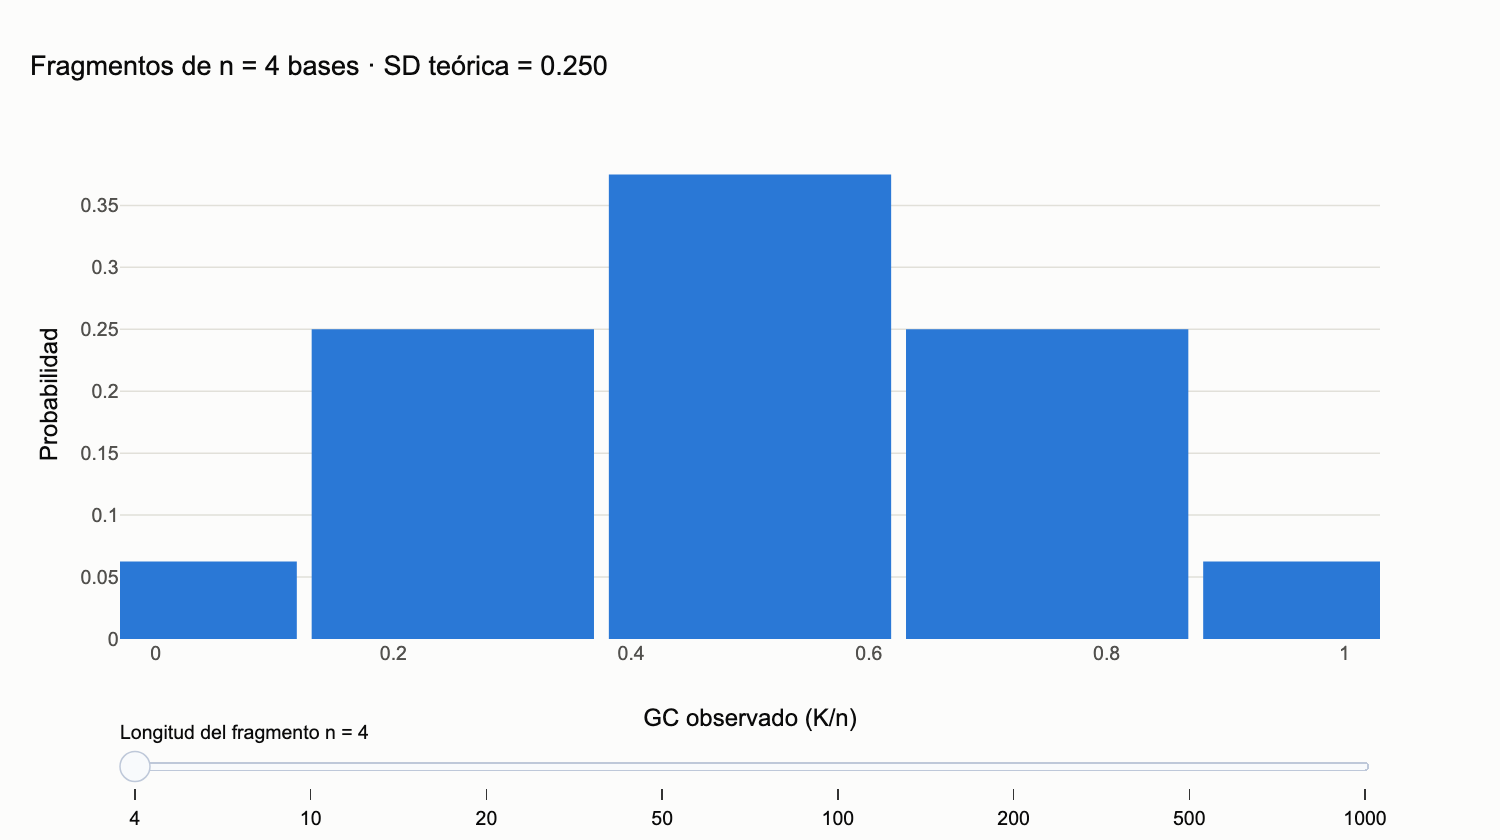

In [13]:
from scipy import stats

p_demo = 0.5
ns = [4, 10, 20, 50, 100, 200, 500, 1000]
fig = go.Figure()
for i, n in enumerate(ns):
    k = np.arange(n + 1)
    fig.add_bar(x=k / n, y=stats.binom.pmf(k, n, p_demo), visible=(i == 0), marker_color=ec.BLUE,
                name=f"n = {n}", hovertemplate="GC observado = %{x:.3f}<br>P = %{y:.4f}<extra></extra>")
steps = [dict(method="update", label=str(n),
              args=[{"visible": [j == i for j in range(len(ns))]},
                    {"title.text": f"Fragmentos de n = {n} bases · SD teórica = {np.sqrt(0.25 / n):.3f}"}])
         for i, n in enumerate(ns)]
fig.update_layout(sliders=[dict(active=0, steps=steps, currentvalue=dict(prefix="Longitud del fragmento n = "),
                                pad=dict(t=50))],
                  title=f"Fragmentos de n = 4 bases · SD teórica = {np.sqrt(0.25 / 4):.3f}",
                  xaxis=dict(title="GC observado (K/n)", range=[-0.03, 1.03]),
                  yaxis=dict(title="Probabilidad"), bargap=0.05, height=480, showlegend=False)
fig.show()

> 🔎 **Qué observamos.** Con $n = 4$ la distribución es ancha y escalonada: casi cualquier valor es plausible. Con
> $n = 1000$ casi toda la probabilidad cae entre 0.47 y 0.53. La forma, además, se vuelve una campana: es el
> teorema central del límite en acción.

### Verificación por simulación

> 🤔 **Antes de ejecutar, prediga:** con ventanas de 5 000 pb de *E. coli*, ¿entre qué valores de GC caerán casi
> todas las ventanas? (Pista: $\mathrm{SD} = \sqrt{0.25/5000} \approx 0.007$ y casi todo cae a ± 2 SD.)

Ahora lo comprobamos **experimentalmente**: generamos 20 000 fragmentos aleatorios para cada longitud y comparamos
el histograma con la curva teórica.

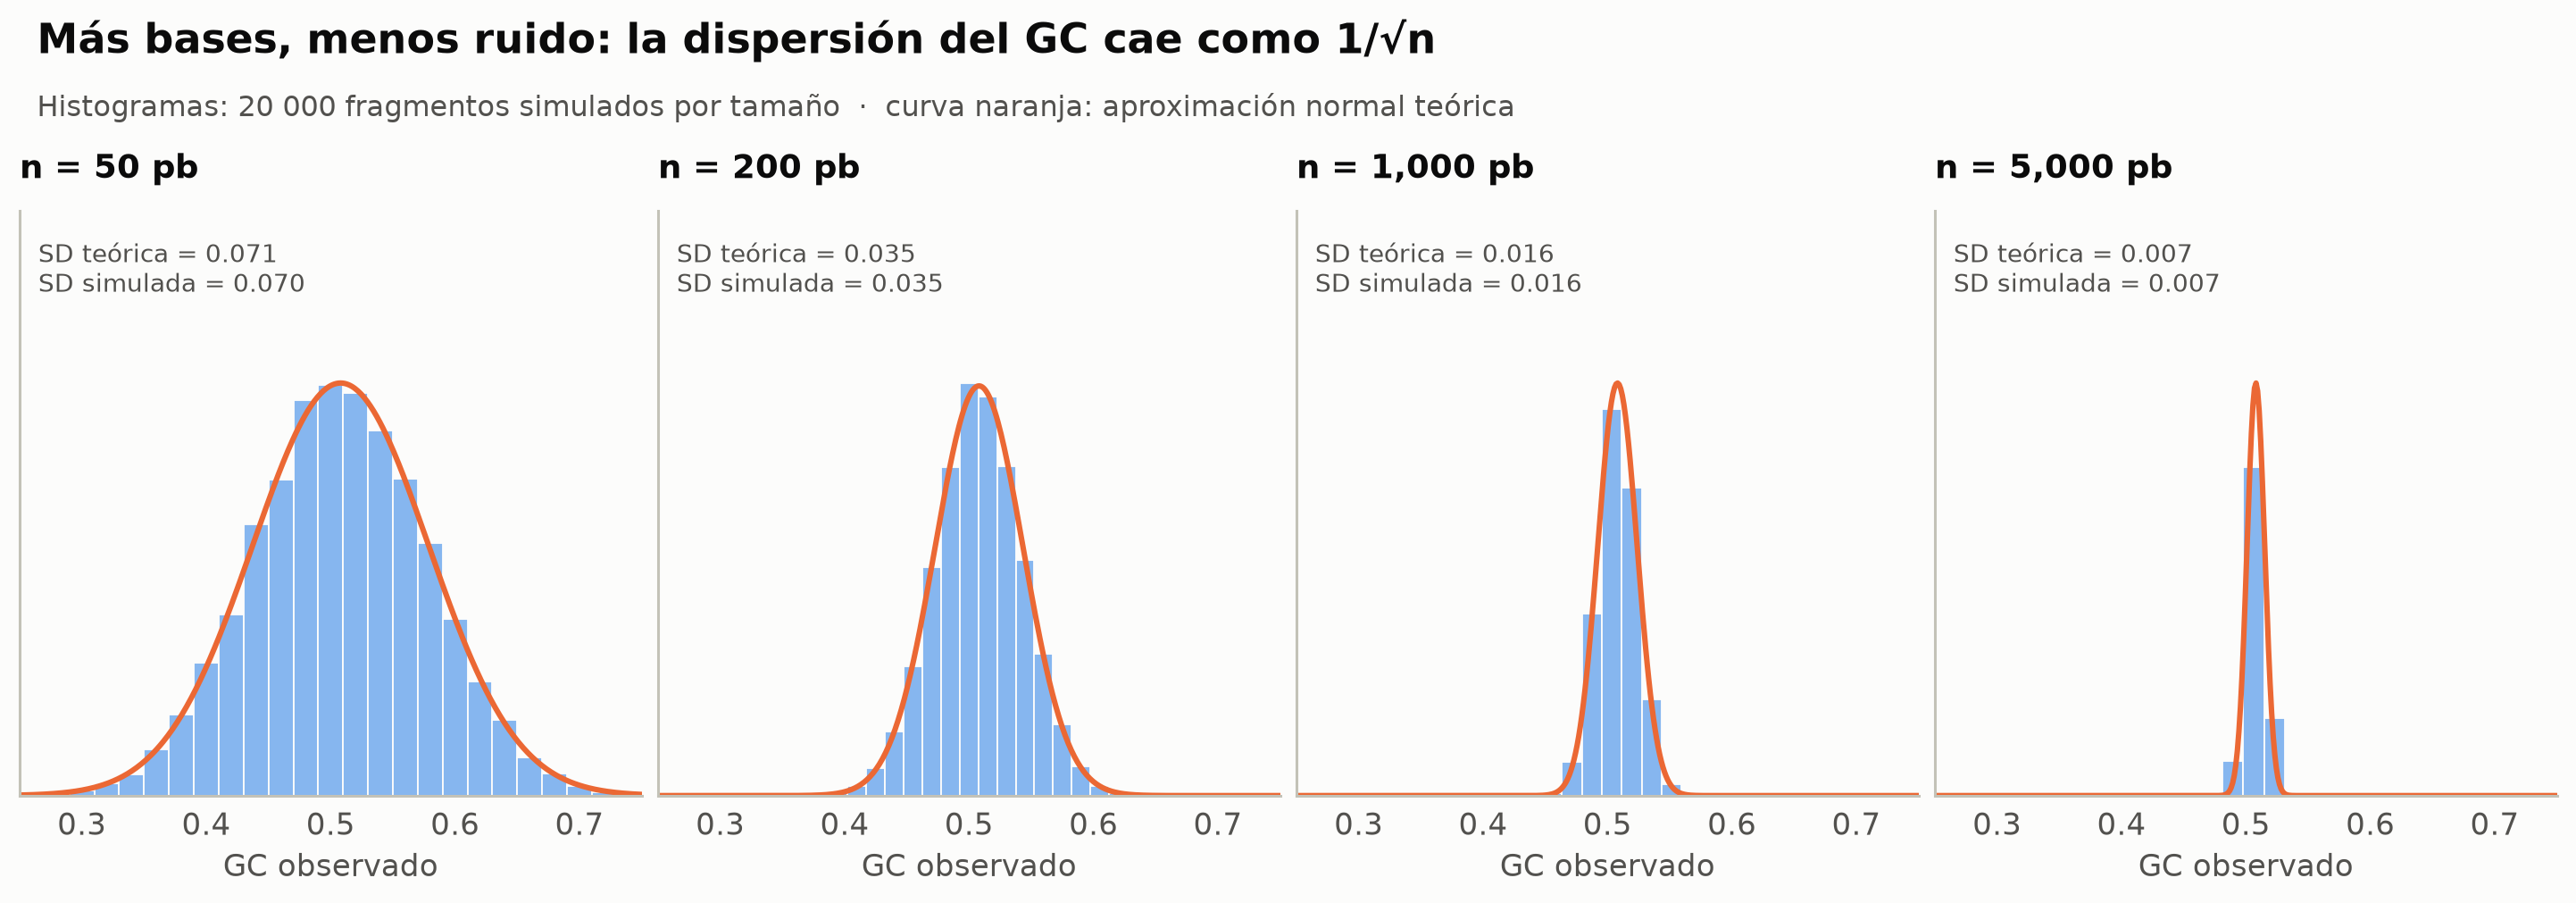

In [14]:
p_true = 0.508          # GC de E. coli
n_sims = 20_000
window_sizes = [50, 200, 1_000, 5_000]

rng = np.random.default_rng(2024)
fig, axes = plt.subplots(1, 4, figsize=(13, 3.8), sharey=False)
for ax, n in zip(axes, window_sizes):
    gc_hat = rng.binomial(n, p_true, size=n_sims) / n          # simulación directa del modelo
    sd = np.sqrt(p_true * (1 - p_true) / n)                    # predicción teórica
    step = max(1, n // 60)                                     # bins alineados con los valores posibles k/n
    bins = (np.arange(0, n + step, step) - 0.5) / n
    ax.hist(gc_hat, bins=bins, density=True, color=ec.SEQ_BLUE[3],
            edgecolor=ec.SURFACE, linewidth=0.6)
    x = np.linspace(0.25, 0.75, 400)
    ax.plot(x, stats.norm.pdf(x, p_true, sd), color=ec.ORANGE, lw=2)
    ax.set_title(f"n = {n:,} pb", fontsize=12)
    ax.text(0.03, 0.95, f"SD teórica = {sd:.3f}\nSD simulada = {gc_hat.std():.3f}",
            transform=ax.transAxes, va="top", fontsize=9, color=ec.INK_2)
    ax.set_yticks([])
    ax.set_xlim(0.25, 0.75)
    ax.set_ylim(0, ax.get_ylim()[1] * 1.35)                    # espacio para el texto
    ax.set_xlabel("GC observado")
    ax.grid(False)
ec.fig_title(fig, "Más bases, menos ruido: la dispersión del GC cae como 1/√n",
             "Histogramas: 20 000 fragmentos simulados por tamaño  ·  curva naranja: aproximación normal teórica")
plt.show()

> 🔎 **Interpretación.** La simulación y la teoría coinciden (compare las SD). Con ventanas de 50 pb, el GC oscila
> fácilmente entre 35 % y 65 % **sin que nada biológico ocurra**. Con 5 000 pb el ruido es de ±1–2 %, y una
> desviación de 8 puntos sería **muy** sospechosa.
>
> **Moraleja bioinformática:** el tamaño de la ventana es una decisión estadística, no estética. Lo usaremos en la
> Lección 1.3 para encontrar **islas genómicas** y el **origen de replicación**.

Podemos cuantificar cuán inusual es un valor con el **puntaje z**:

$$
z \;=\; \frac{\hat{p} - p}{\sqrt{p(1-p)/n}}
$$

que mide "cuántas desviaciones estándar" se aleja lo observado de lo esperado.

**Ejemplo a mano.** Un fragmento de $n = 1\,000$ pb de *E. coli* ($p = 0.508$) tiene 58 % de GC:

$$
z = \frac{0.58 - 0.508}{\sqrt{0.508 \times 0.492 / 1000}} = \frac{0.072}{0.0158} \approx 4.6
$$

Un valor a 4.6 desviaciones estándar ocurre por azar menos de una vez en 100 000: ese fragmento sí merece
atención. Con $n = 100$ el mismo 58 % daría $z \approx 1.4$, perfectamente normal.

In [15]:
def gc_zscore(gc_obs: float, p: float, n: int) -> float:
    return (gc_obs - p) / np.sqrt(p * (1 - p) / n)

for n in [100, 1_000, 10_000]:
    z = gc_zscore(0.58, p_true, n)
    pval = 2 * stats.norm.sf(abs(z))                 # prueba de dos colas
    print(f"GC = 58 % en {n:>6,} pb  →  z = {z:5.2f}   p-valor ≈ {pval:.2g}")

GC = 58 % en    100 pb  →  z =  1.44   p-valor ≈ 0.15
GC = 58 % en  1,000 pb  →  z =  4.55   p-valor ≈ 5.3e-06
GC = 58 % en 10,000 pb  →  z = 14.40   p-valor ≈ 5e-47


> ✅ **Compruebe su comprensión.** (1) Si multiplica por 4 la longitud de la ventana, ¿por qué factor se reduce la
> SD? (2) ¿Por qué un GC de 58 % es "normal" en 100 pb pero "sospechoso" en 10 000 pb, si es el mismo porcentaje?

## 6. 🎬 Animación: una ventana deslizante recorre un genoma

Simulemos un genoma de 60 kb con GC = 50 % en el que **insertamos una isla** de 8 kb con GC = 62 % (como un
fragmento adquirido de otra bacteria). Una **ventana deslizante** calcula el GC local mientras recorre el genoma.

Imagine que desliza una **lupa** de ancho fijo sobre un texto larguísimo y, en cada posición, anota qué fracción de
las letras bajo la lupa son G o C. Al final obtiene una curva: el GC **local** a lo largo del genoma. Donde la curva
se eleva o se hunde de manera sostenida, algo distinto ocurre en esa región.

**El truco de la suma acumulada.** Recalcular el GC de cada ventana desde cero costaría $w$ operaciones por ventana.
En su lugar calculamos una sola vez $S_i$ = número de G o C en las primeras $i$ bases. Entonces el número de GC en la
ventana $[i, i+w)$ es simplemente

$$
\text{GC en la ventana } [i, i+w) \;=\; S_{i+w} - S_i
$$

**Ejemplo a mano.** Para `GATCCG`, marcando GC con 1 queda `1 0 0 1 1 1`, y la suma acumulada es
$S = [0, 1, 1, 1, 2, 3, 4]$. La ventana de 3 bases que empieza en $i = 2$ (`TCC`) tiene $S_5 - S_2 = 3 - 1 = 2$
bases GC, es decir 2/3. ¡Una resta en lugar de tres sumas!

> 🤔 **Antes de ejecutar, prediga:** ¿cómo se verá la curva al pasar por la isla? ¿Un salto brusco o una rampa? ¿De
> qué ancho será la rampa?

Abajo verá primero una **vista previa** (GIF); al ejecutar la celda de código obtendrá la versión con controles para
reproducir, pausar y avanzar cuadro a cuadro.

![Vista previa: una ventana de 2 kb recorre un genoma simulado y revela una isla rica en GC.](https://raw.githubusercontent.com/juvenalyosa/bioinformatica-practica/main/assets/modulo-00-preparacion/0.1_ventana_gc.gif)

*Vista previa: una ventana de 2 kb recorre un genoma simulado y revela una isla rica en GC.*

In [16]:
rng = np.random.default_rng(7)
genome = random_dna(26_000, 0.50, rng) + random_dna(8_000, 0.62, rng) + random_dna(26_000, 0.50, rng)
island = (26_000, 34_000)

def sliding_gc(seq: str, window: int, step: int):
    arr = to_array(seq)
    is_gc = ((arr == ord("G")) | (arr == ord("C"))).astype(np.int64)
    csum = np.concatenate([[0], np.cumsum(is_gc)])          # S_0 = 0, S_1, ..., S_L
    starts = np.arange(0, len(arr) - window + 1, step)
    return starts + window // 2, (csum[starts + window] - csum[starts]) / window

window = 2_000
centers, gc_curve = sliding_gc(genome, window=window, step=250)

fig, (ax_g, ax) = plt.subplots(2, 1, figsize=(9, 4.6), height_ratios=[1, 5], sharex=True)
# Pista superior: el genoma como una barra, con la isla resaltada
ax_g.axvspan(0, len(genome), color=ec.GRID)
ax_g.axvspan(*island, color=ec.SEQ_BLUE[4])
ax_g.text(np.mean(island), 0.5, "isla (GC 62 %)", ha="center", va="center", fontsize=9, color="white", fontweight="bold")
ax_g.set_yticks([]); ax_g.grid(False)
for s in ax_g.spines.values(): s.set_visible(False)
from matplotlib.patches import Rectangle
lens = Rectangle((0, 0), window, 1, color=ec.ORANGE, transform=ax_g.get_xaxis_transform())
ax_g.add_patch(lens)

ax.axhline(0.5, color=ec.BASELINE, lw=1)
ax.axvspan(*island, color=ec.SEQ_BLUE[0], zorder=0)
line, = ax.plot([], [], color=ec.BLUE, lw=2)
dot, = ax.plot([], [], "o", color=ec.BLUE, markersize=8, markeredgecolor=ec.SURFACE, markeredgewidth=2)
ax.set_xlim(0, len(genome)); ax.set_ylim(0.40, 0.72)
ax.set_xlabel("Posición en el genoma (pb)"); ax.set_ylabel("GC en la ventana")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
ax_g.set_title("Una ventana de 2 kb recorre el genoma y revela la isla GC", loc="left")

n_frames = 50
idx = np.linspace(1, len(centers), n_frames).astype(int)

def update(f):
    k = idx[f]
    line.set_data(centers[:k], gc_curve[:k])
    dot.set_data([centers[k - 1]], [gc_curve[k - 1]])
    start = centers[k - 1] - window // 2
    lens.set_x(start)                      # mueve la "lupa"
    return line, dot, lens

ec.animate(fig, update, frames=n_frames, interval=90, name="0.1_ventana_gc")

▶️ Ejecute esta celda para ver la animación con controles (la vista previa GIF está en la celda de texto de arriba).

> ▶️ Use los controles bajo la figura para reproducir, pausar o avanzar cuadro a cuadro.
> Observe que **fuera** de la isla la curva oscila alrededor de 0.50 con una amplitud de
> $\approx 2 \times \sqrt{0.25/2000} \approx 0.022$ — exactamente lo que predijo el modelo binomial.
> Y la curva **no** salta de golpe en el borde de la isla: sube en una **rampa del ancho de la ventana** (2 kb),
> porque durante ese tramo la lupa contiene una parte de isla y una parte de genoma normal.

### 🖱️ Explore el tamaño de la ventana

El tamaño de ventana es un compromiso: ventanas pequeñas ven detalles pero son ruidosas; ventanas grandes son suaves
pero borran los bordes. Use el control deslizante para verlo usted mismo.

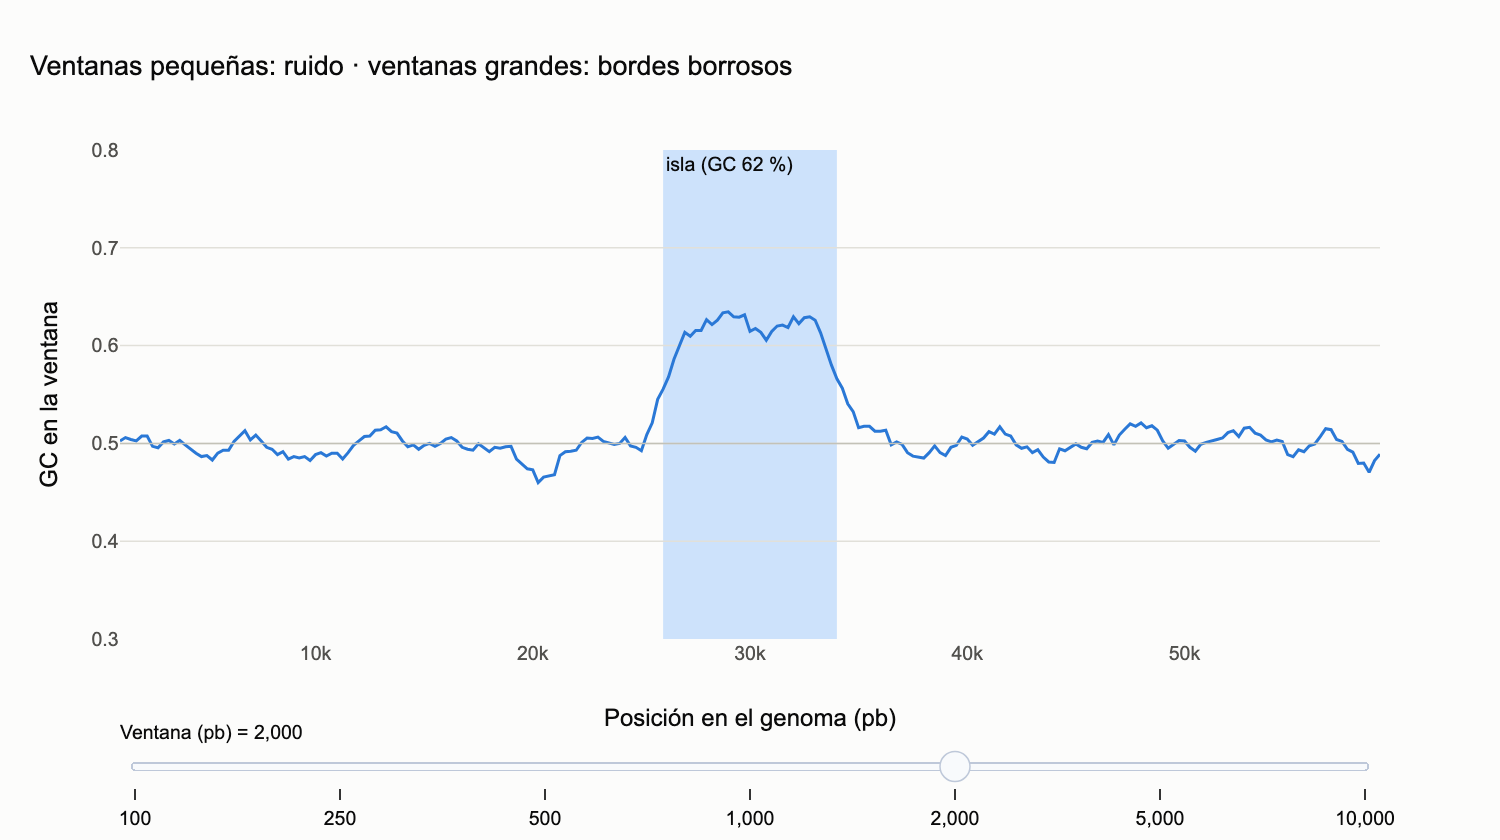

In [17]:
windows = [100, 250, 500, 1000, 2000, 5000, 10000]
fig = go.Figure()
for i, w in enumerate(windows):
    c, g = sliding_gc(genome, window=w, step=max(w // 8, 25))
    fig.add_scatter(x=c, y=g, mode="lines", line=dict(color=ec.BLUE, width=2), visible=(i == 4),
                    name=f"{w} pb", hovertemplate="posición %{x:,} pb<br>GC = %{y:.3f}<extra></extra>")
steps = [dict(method="update", label=f"{w:,}", args=[{"visible": [j == i for j in range(len(windows))]}])
         for i, w in enumerate(windows)]
fig.add_vrect(x0=island[0], x1=island[1], fillcolor=ec.SEQ_BLUE[0], line_width=0, layer="below",
              annotation_text="isla (GC 62 %)", annotation_position="top left")
fig.add_hline(y=0.5, line_color=ec.BASELINE, line_width=1)
fig.update_layout(sliders=[dict(active=4, steps=steps, currentvalue=dict(prefix="Ventana (pb) = "), pad=dict(t=50))],
                  title="Ventanas pequeñas: ruido · ventanas grandes: bordes borrosos",
                  xaxis_title="Posición en el genoma (pb)", yaxis_title="GC en la ventana",
                  yaxis_range=[0.3, 0.8], height=480, showlegend=False)
fig.show()

## 7. Anatomía de una figura profesional

Una figura de publicación **no es decoración**: es un argumento. Compare la misma información con el estilo por
defecto y con el estilo del curso:

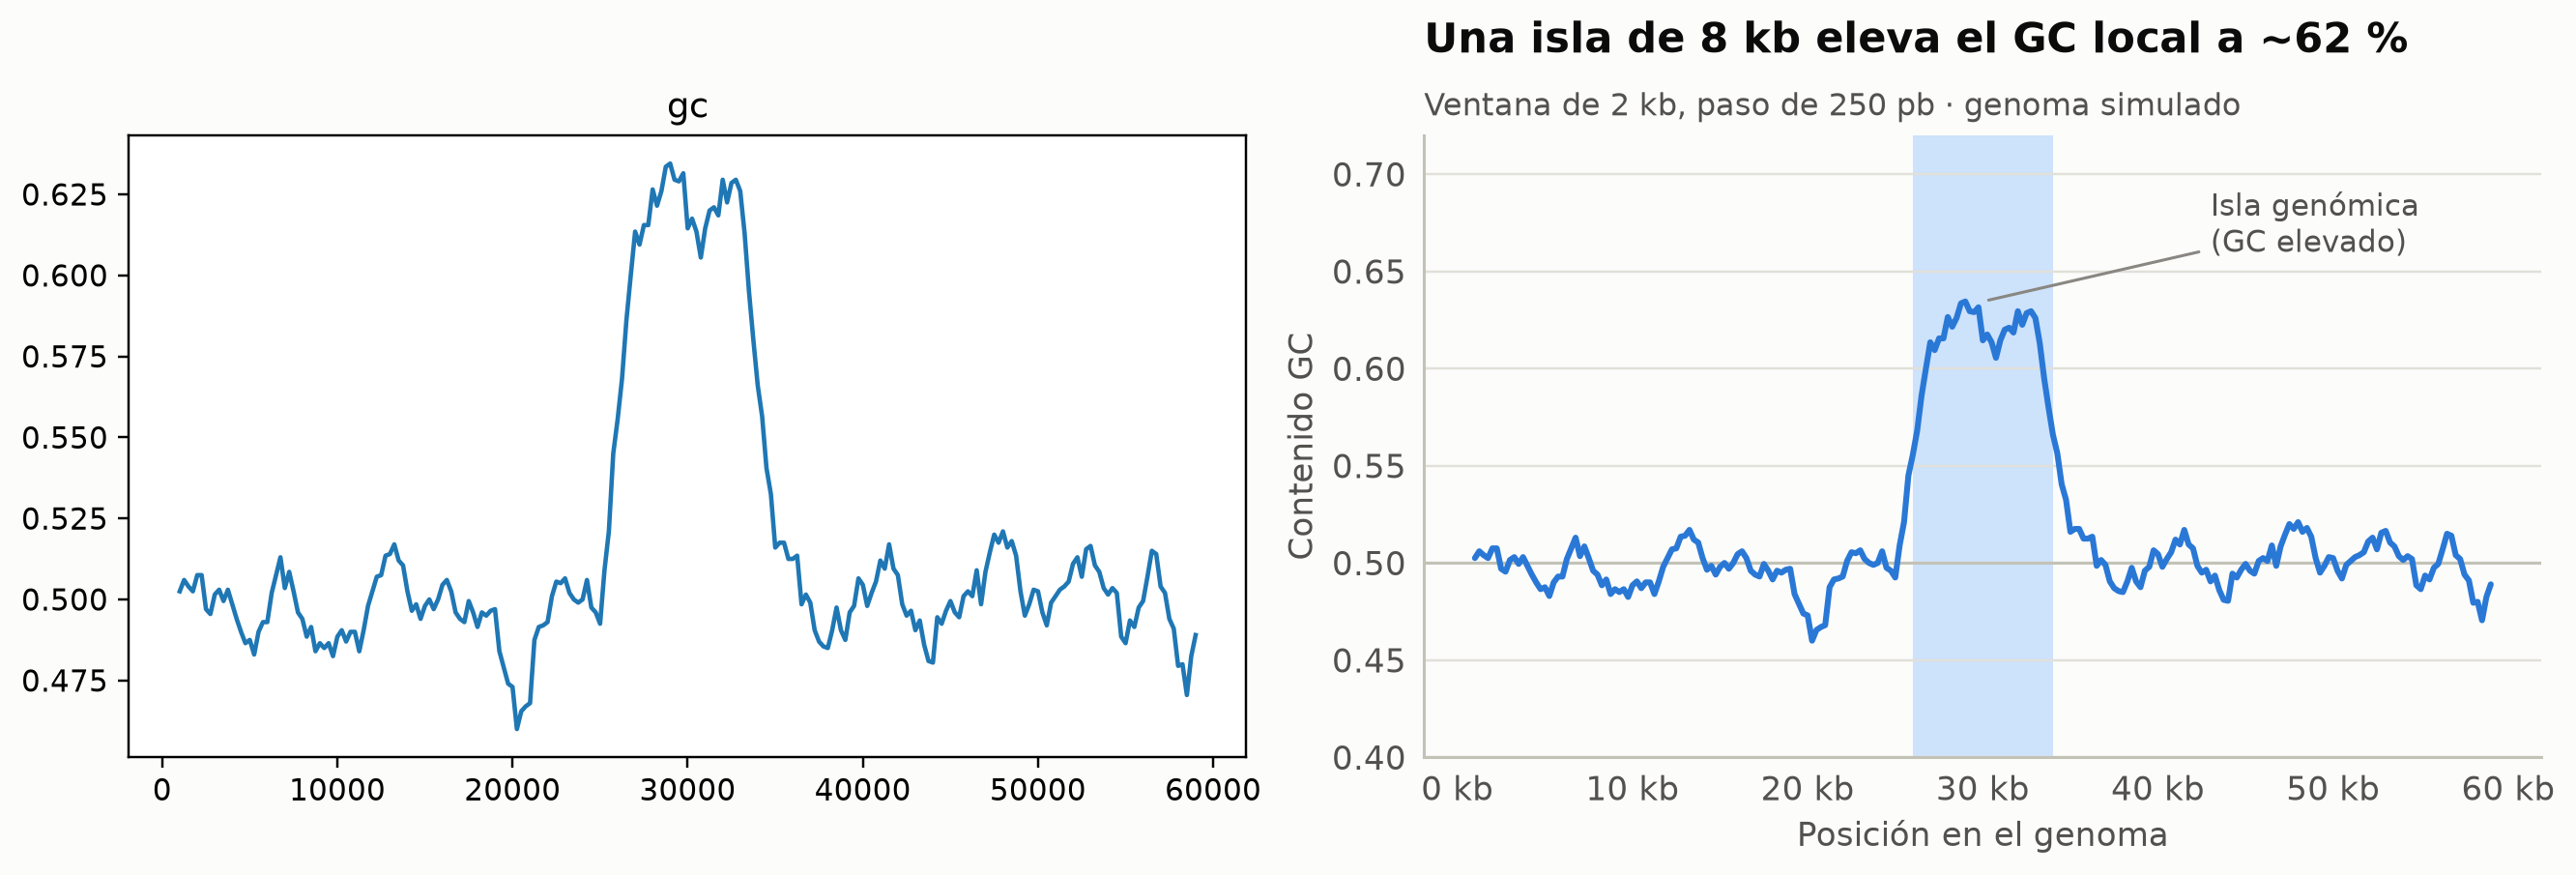

In [18]:
fig = plt.figure(figsize=(12, 4))
with plt.style.context("default"):
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.plot(centers, gc_curve)
    ax1.set_title("gc")

ax2 = fig.add_subplot(1, 2, 2)
ax2.axvspan(*island, color=ec.SEQ_BLUE[0], zorder=0)
ax2.axhline(0.5, color=ec.BASELINE, lw=1)
ax2.plot(centers, gc_curve, color=ec.BLUE)
ax2.annotate("Isla genómica\n(GC elevado)", xy=(30_000, gc_curve.max()), xytext=(43_000, 0.66),
             arrowprops=dict(arrowstyle="-", color=ec.MUTED, lw=1), fontsize=10, color=ec.INK_2)
ax2.set_ylim(0.40, 0.72)
ax2.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
ax2.set_xlabel("Posición en el genoma"); ax2.set_ylabel("Contenido GC")
ec.title(ax2, "Una isla de 8 kb eleva el GC local a ~62 %", "Ventana de 2 kb, paso de 250 pb · genoma simulado")
plt.show()

**Las 7 reglas del curso para figuras** (las aplicaremos en todas las lecciones):

1. **El título dice la conclusión**, no el nombre de la variable ("Una isla eleva el GC", no "gc").
2. **Subtítulo con el contexto**: tamaño de muestra, parámetros, origen de los datos.
3. **Ejes con unidades** y números legibles (`kb`, `%`, escalas log cuando corresponda).
4. **Etiquetas directas** en lugar de obligar a buscar en la leyenda; nunca un número sobre cada punto.
5. **Color con propósito**: categórico para identidad, una sola gama para magnitud, dos gamas + gris neutro para
   valores con signo. Paleta segura para daltonismo y **nunca** el color como único código.
6. **Un solo eje Y.** Si dos medidas tienen escalas distintas, use dos paneles.
7. **Tinta mínima**: rejilla tenue, sin marcos innecesarios, sin efectos 3D.

## ✍️ Ejercicios

**Ejercicio 1 — Complemento reverso.** Las dos hebras del ADN son antiparalelas y complementarias
(A↔T, C↔G). Escriba `reverse_complement(seq)` usando un diccionario. Compruebe que
`reverse_complement("ATGC") == "GCAT"`.

**Ejercicio 2 — Contenido GC en la tercera posición del codón (GC3).** En genes codificantes la tercera posición
es la más libre de variar. Calcule el GC sólo de las posiciones 3, 6, 9, … de una secuencia (pista: `seq[2::3]`).

**Ejercicio 3 — Poder estadístico.** ¿Qué tamaño de ventana $n$ necesita para que un GC de 55 % en un genoma de
50 % dé $z \ge 3$? Despeje $n$ de la fórmula del puntaje z y verifique con `gc_zscore`.

**Ejercicio 4 — Ventana y resolución.** Repita la figura de la sección 6 con ventanas de 200, 2 000 y 10 000 pb en
tres paneles. ¿Qué se gana y qué se pierde al agrandar la ventana?

Intente resolverlos antes de abrir las soluciones (haga doble clic en la celda para ver el código).

In [19]:
#@title 🔑 Solución — Ejercicio 1 { display-mode: "form" }
COMPLEMENT = {"A": "T", "T": "A", "C": "G", "G": "C", "N": "N"}

def reverse_complement(seq: str) -> str:
    return "".join(COMPLEMENT[b] for b in reversed(seq.upper()))

assert reverse_complement("ATGC") == "GCAT"
print(reverse_complement(dna))

CTACGCGATATCGCGCCGTTAAGCCTAGCTAGCGTACGCCAT


In [20]:
#@title 🔑 Solución — Ejercicio 2 { display-mode: "form" }
coding = random_dna(3_000, 0.5, np.random.default_rng(1))
print(f"GC total = {gc_content(coding):.3f}   GC3 = {gc_content(coding[2::3]):.3f}")

GC total = 0.493   GC3 = 0.499


In [21]:
#@title 🔑 Solución — Ejercicio 3 { display-mode: "form" }
# z = (p_obs - p) / sqrt(p(1-p)/n)  =>  n = z^2 p (1-p) / (p_obs - p)^2
p, p_obs, z_target = 0.50, 0.55, 3
n_needed = int(np.ceil(z_target**2 * p * (1 - p) / (p_obs - p) ** 2))
print("n necesario =", n_needed, "pb  →  z =", round(gc_zscore(p_obs, p, n_needed), 2))

n necesario = 900 pb  →  z = 3.0


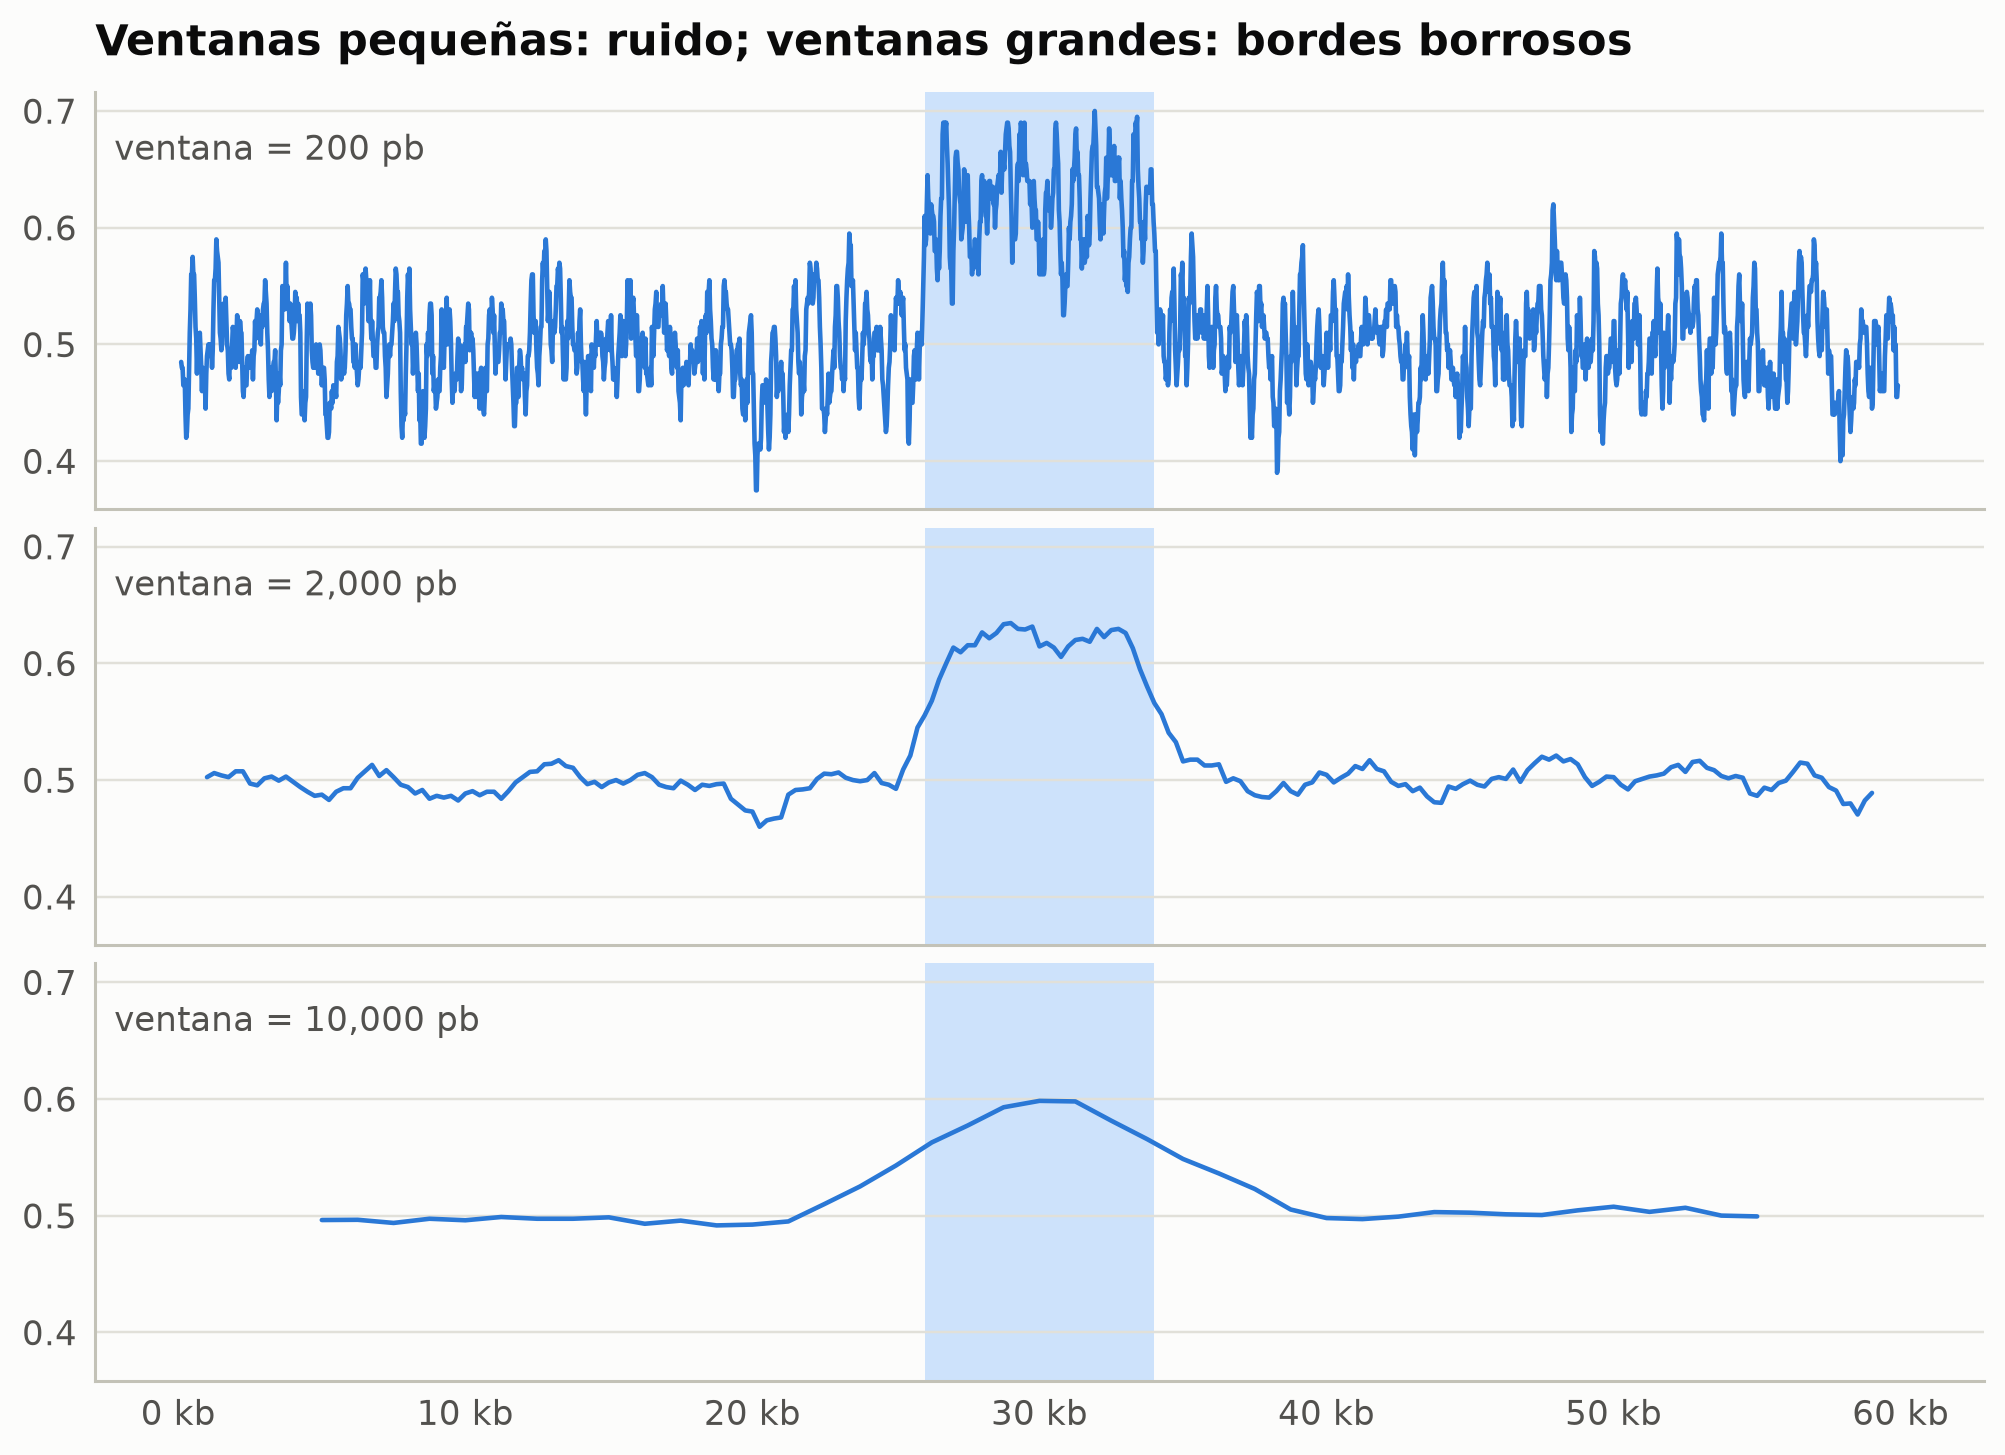

In [22]:
#@title 🔑 Solución — Ejercicio 4 { display-mode: "form" }
fig, axes = plt.subplots(3, 1, figsize=(9, 6.5), sharex=True, sharey=True)
for ax, w in zip(axes, [200, 2_000, 10_000]):
    c, g = sliding_gc(genome, window=w, step=max(w // 8, 25))
    ax.axvspan(*island, color=ec.SEQ_BLUE[0], zorder=0)
    ax.plot(c, g, color=ec.BLUE, lw=1.5)
    ax.text(0.01, 0.9, f"ventana = {w:,} pb", transform=ax.transAxes, color=ec.INK_2, va="top")
axes[-1].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1000:.0f} kb"))
axes[0].set_title("Ventanas pequeñas: ruido; ventanas grandes: bordes borrosos", loc="left")
plt.show()

## 📌 Resumen

* Un **notebook** es un cuaderno de laboratorio ejecutable: protocolo (texto) + experimento (código) + resultados.
* En Python el ADN es un `str`; contamos con `dict`, y escalamos con **`numpy`** (vectorización: una operación sobre
  millones de bases a la vez).
* Los gráficos **interactivos** (`plotly`) sirven para explorar; los estáticos (`matplotlib`) para comunicar.
* **`pandas`** organiza datos biológicos en tablas que se filtran y resumen en una línea.
* El contenido GC es una proporción $\hat p$ cuyo ruido aleatorio es $\sqrt{p(1-p)/n}$: **el tamaño de muestra decide
  si una diferencia es interesante**.
* Una figura profesional comunica una conclusión: título-conclusión, contexto, etiquetas directas, color con propósito.

**Próxima lección (0.2):** Biopython y herramientas de línea de comandos — descargaremos un genoma real del NCBI.

## 📚 Para profundizar

* VanderPlas, J. *Python Data Science Handbook* (O'Reilly) — gratuito en línea: capítulos de NumPy y Pandas.
* Haddock, S. & Dunn, C. *Practical Computing for Biologists* (Sinauer).
* Rougier, N. P. *et al.* (2014). Ten Simple Rules for Better Figures. *PLoS Comput Biol* 10(9): e1003833.

---

<sub>**Bioinformática Práctica** · © 2026 Juvenal Yosa, PhD · [juvenal.yosa@gmail.com](mailto:juvenal.yosa@gmail.com) · Código bajo licencia MIT ·
Desarrollado con **Claude** (Anthropic) como copiloto.</sub>

[![Copiloto: Claude](https://img.shields.io/badge/Copiloto-Claude-D97757?logo=claude&logoColor=white)](https://claude.ai)